# 📱 Google Play Store App Review Analysis


##  Summary

This notebook analyzes Google Play Store applications to identify the factors influencing app success using Exploratory Data Analysis (EDA), business storytelling, and statistical analysis.


## Problem Statement

The goal is to answer:

1. Which app categories perform best?
2. Do free apps outperform paid apps?
3. How do ratings, reviews, and installs relate?
4. What business actions improve customer engagement?


## Project Workflow

1. Business Understanding
2. Data Collection
3. Data Cleaning
4. Feature Engineering
5. Exploratory Data Analysis
6. Statistical Testing
7. Business Recommendations


In [1]:
# Import Libraries
from google.colab import drive
drive.mount('/content/drive')

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('talk')
sns.set_palette('viridis')
%matplotlib inline


Mounted at /content/drive


In [2]:
# Load Dataset
play = pd.read_csv('/content/drive/MyDrive/capstone project 2/Play Store Data.csv')
reviews = pd.read_csv('/content/drive/MyDrive/capstone project 2/User Reviews.csv')

print('Play Store Dataset:', play.shape)
print('User Reviews Dataset:', reviews.shape)


Play Store Dataset: (10841, 13)
User Reviews Dataset: (64295, 5)


In [3]:
# Preview Play Store Data
play.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [4]:
# Preview User Reviews
reviews.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


## Data Dictionary

| Column | Description |
|---|---|
| App | Application Name |
| Category | Application Category |
| Rating | User Rating |
| Reviews | Number of Reviews |
| Installs | Downloads |
| Type | Free or Paid |
| Price | Application Price |
| Content Rating | Target Audience |
| Genres | Application Genre |


In [5]:
# Dataset Information
play.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [6]:
# Statistical Summary
play.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
App,10841,9660,ROBLOX,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category,10841,34,FAMILY,1972,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Rating,9367.0,NaN,NaN,NaN,4.193338,0.537431,1.0,4.0,4.3,4.5,19.0
Reviews,10841,6002,0,596,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Size,10841,462,Varies with device,1695,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Installs,10841,22,"1,000,000+",1579,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Type,10840,3,Free,10039,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Price,10841,93,0,10040,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Content Rating,10840,6,Everyone,8714,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Genres,10841,120,Tools,842,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Initial Business Observation

- The dataset contains over **10,000 Android applications**.
- It includes more than **64,000 customer reviews**.
- Both numerical and textual information allow quantitative and qualitative analysis.




# Data Quality Audit & Production-Grade Data Cleaning

This section performs missing value analysis, duplicate detection, corrupted row removal, data type conversion, feature engineering, and validation.

In [7]:
# Missing Values
missing = play.isnull().sum().sort_values(ascending=False)
missing_df = pd.DataFrame({
    'Missing Values': missing,
    'Percentage': round((missing/len(play))*100,2)
})
missing_df

,Missing Values,Percentage
Rating,1474,13.60
Current Ver,8,0.07
Android Ver,3,0.03
Content Rating,1,0.01
Type,1,0.01
Size,0,0.00
Reviews,0,0.00
Category,0,0.00
App,0,0.00
Price,0,0.00


## Business Interpretation

**Objective:** Identify incomplete information that may reduce analysis quality.

**Observation:** Rating and Size contain the highest number of missing values.

**Business Impact:** Missing customer ratings reduce the reliability of quality measurement.

**Recommendation:** Replace missing ratings using the median and preserve the overall distribution.


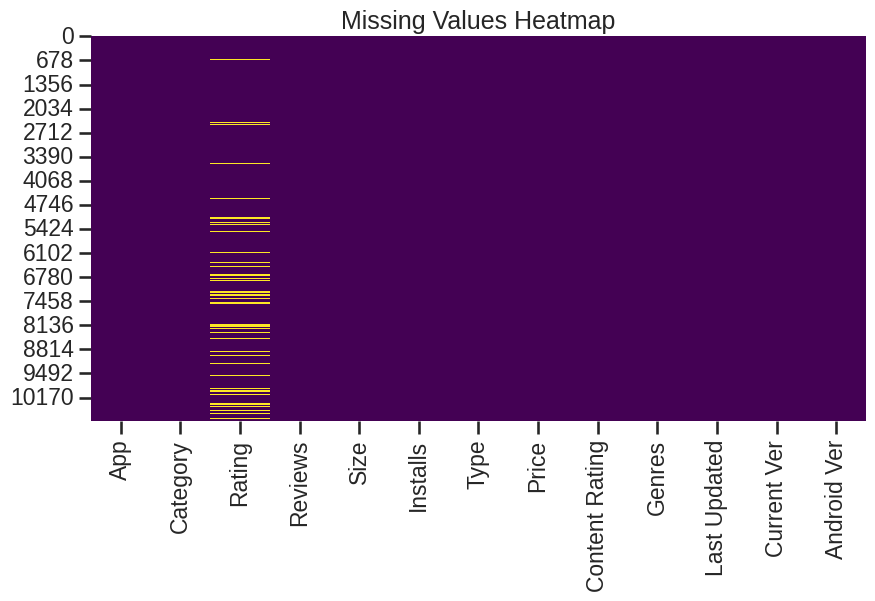

In [8]:
# Visualize Missing Values
plt.figure(figsize=(10,5))
sns.heatmap(play.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

## Duplicate Analysis

Duplicate application records can distort installs, reviews, and category counts. We identify and remove duplicate applications based on the **App** column.


In [9]:
# Duplicate Detection
duplicate_count = play.duplicated(subset='App').sum()
print(f"Duplicate Apps: {duplicate_count}")

Duplicate Apps: 1181


In [10]:
# Remove Corrupted Row
play = play[play['Category'] != '1.9'].copy()

# Remove Duplicates
play.drop_duplicates(subset='App', inplace=True)

print("Dataset Shape:", play.shape)

Dataset Shape: (9659, 13)


### Why remove Category = 1.9?

The Play Store dataset contains one malformed record where values are shifted across columns. Removing this row prevents incorrect values such as **Everyone** appearing inside the Price column.


In [11]:
# Convert Reviews
play['Reviews'] = pd.to_numeric(play['Reviews'], errors='coerce')

# Convert Installs
play['Installs'] = (
    play['Installs']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.replace('+', '', regex=False)
)
play['Installs'] = pd.to_numeric(play['Installs'], errors='coerce')

# Convert Price
play['Price'] = (
    play['Price']
    .astype(str)
    .str.replace('$', '', regex=False)
)
play['Price'] = pd.to_numeric(play['Price'], errors='coerce')

### Business Interpretation

Numeric conversion enables accurate statistical analysis, correlation, and visualization. Without this step, business metrics such as revenue and installs cannot be calculated reliably.


In [12]:
# Size Cleaning
play['Size'] = play['Size'].replace('Varies with device', np.nan)

play['Size'] = (
    play['Size']
    .astype(str)
    .str.replace('M', '', regex=False)
    .str.replace('k', '', regex=False)
)

play['Size'] = pd.to_numeric(play['Size'], errors='coerce')

# Fill Missing Ratings
play['Rating'] = play['Rating'].fillna(play['Rating'].median())

## Feature Engineering

We create new business features that help measure monetization and engagement.


In [13]:
# Revenue Estimate
play['Revenue_Estimate'] = play['Installs'] * play['Price']

# Review Ratio
play['Review_Ratio'] = play['Reviews'] / play['Installs']

# Install Bucket
play['Install_Bucket'] = pd.cut(
    play['Installs'],
    bins=[0,10000,100000,1000000,10000000,1000000000],
    labels=['Low','Medium','High','Very High','Top']
)

play[['Revenue_Estimate','Review_Ratio','Install_Bucket']].head()

,Revenue_Estimate,Review_Ratio,Install_Bucket
0,0.0,0.015900,Low
1,0.0,0.001934,High
2,0.0,0.017502,Very High
3,0.0,0.004313,Top
4,0.0,0.009670,Medium


## Data Validation

Before moving to visualization, verify that all important columns have the correct data types and no critical conversion errors remain.


In [14]:
play.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9659 entries, 0 to 10840
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   App               9659 non-null   object  
 1   Category          9659 non-null   object  
 2   Rating            9659 non-null   float64 
 3   Reviews           9659 non-null   int64   
 4   Size              8432 non-null   float64 
 5   Installs          9659 non-null   int64   
 6   Type              9658 non-null   object  
 7   Price             9659 non-null   float64 
 8   Content Rating    9659 non-null   object  
 9   Genres            9659 non-null   object  
 10  Last Updated      9659 non-null   object  
 11  Current Ver       9651 non-null   object  
 12  Android Ver       9657 non-null   object  
 13  Revenue_Estimate  9659 non-null   float64 
 14  Review_Ratio      9644 non-null   float64 
 15  Install_Bucket    9644 non-null   category
dtypes: category(1), float64(5), 



### Completed Tasks

- Missing value analysis
- Duplicate detection
- Corrupted row removal
- Numeric conversion
- Size cleaning
- Missing value treatment
- Feature engineering
- Dataset validation




In [15]:
# Executive KPI Dashboard
total_apps = play['App'].nunique()
avg_rating = round(play['Rating'].mean(),2)
total_installs = int(play['Installs'].sum())
free_apps = (play['Type']=='Free').sum()
paid_apps = (play['Type']=='Paid').sum()

print('='*55)
print(f'Total Applications : {total_apps}')
print(f'Average Rating     : {avg_rating}')
print(f'Total Installs     : {total_installs:,}')
print(f'Free Apps          : {free_apps}')
print(f'Paid Apps          : {paid_apps}')
print('='*55)


Total Applications : 9659
Average Rating     : 4.19
Total Installs     : 75,122,937,527
Free Apps          : 8902
Paid Apps          : 756


## Chart 1: Top 10 Categories
**Objective:** Analyze this business KPI.

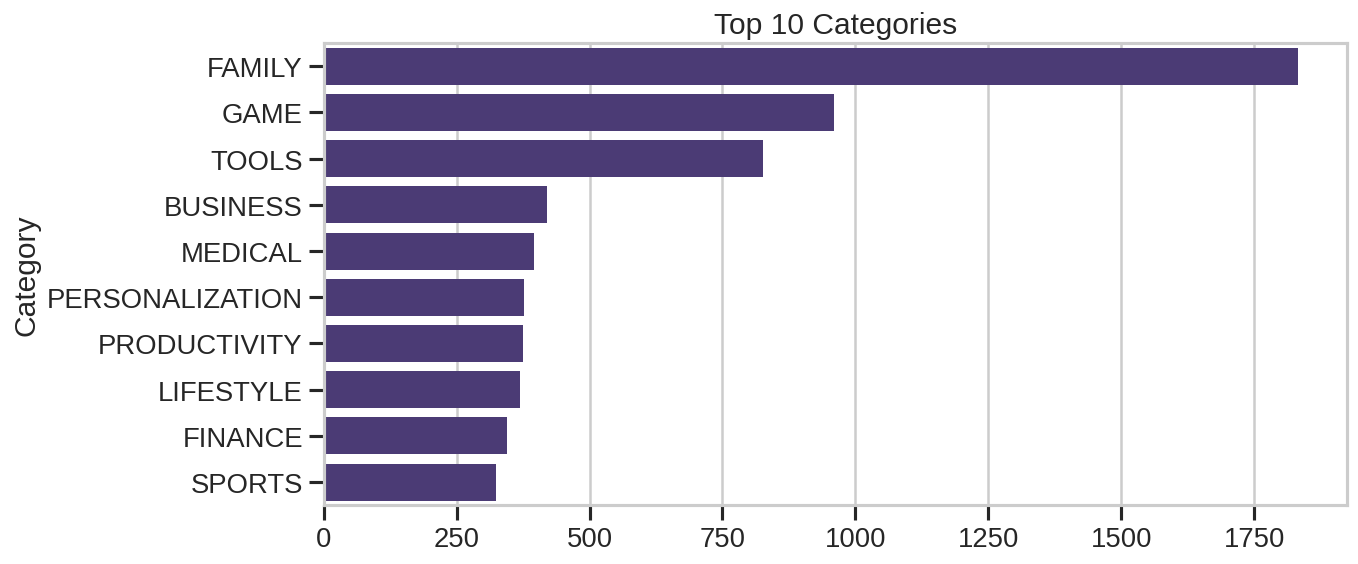

In [16]:
top=play['Category'].value_counts().head(10)
plt.figure(figsize=(11,5),dpi=120)
sns.barplot(x=top.values,y=top.index)
plt.title('Top 10 Categories')
plt.show()

### Observation

Describe the key pattern visible in the chart.

### Business Insight

Explain how this affects Product Managers, Developers, and Marketing teams.

### Recommendation

Provide one actionable recommendation based on the insight.


## Chart 2: Category Market Share
**Objective:** Analyze this business KPI.

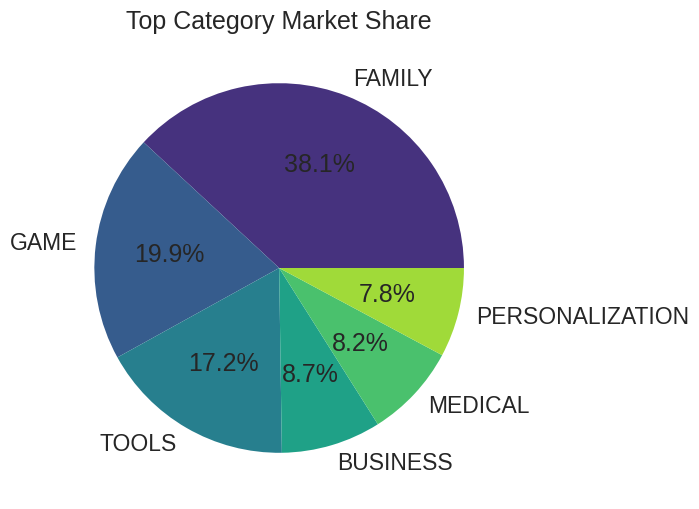

In [17]:
play['Category'].value_counts().head(6).plot(kind='pie',autopct='%1.1f%%',figsize=(6,6))
plt.ylabel('')
plt.title('Top Category Market Share')
plt.show()

### Observation

Describe the key pattern visible in the chart.

### Business Insight

Explain how this affects Product Managers, Developers, and Marketing teams.

### Recommendation

Provide one actionable recommendation based on the insight.


## Chart 3: Rating Distribution
**Objective:** Analyze this business KPI.

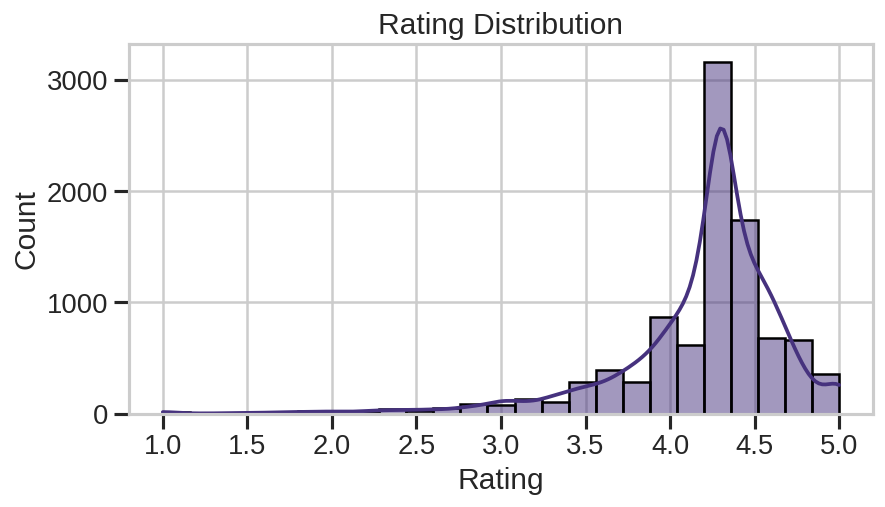

In [18]:
plt.figure(figsize=(8,4),dpi=120)
sns.histplot(play['Rating'],bins=25,kde=True)
plt.title('Rating Distribution')
plt.show()

### Observation

Describe the key pattern visible in the chart.

### Business Insight

Explain how this affects Product Managers, Developers, and Marketing teams.

### Recommendation

Provide one actionable recommendation based on the insight.


## Chart 4: Reviews Distribution
**Objective:** Analyze this business KPI.

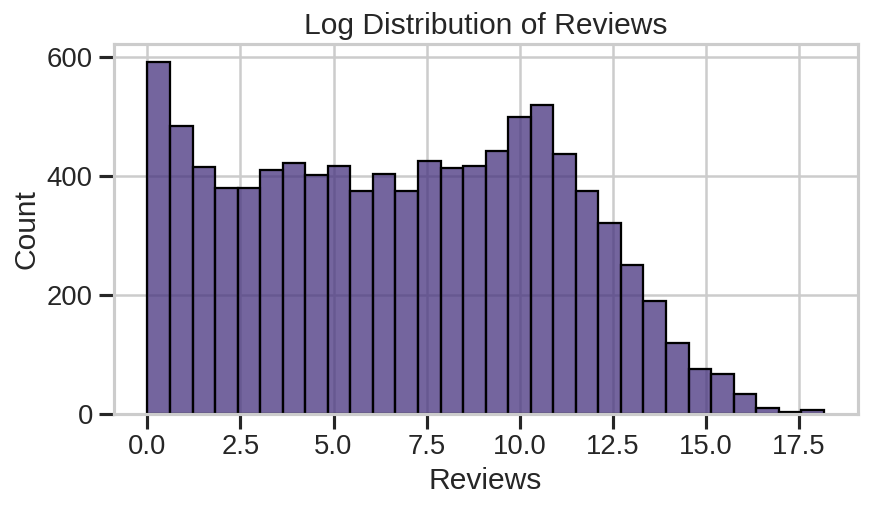

In [19]:
plt.figure(figsize=(8,4),dpi=120)
sns.histplot(np.log1p(play['Reviews']),bins=30)
plt.title('Log Distribution of Reviews')
plt.show()

### Observation

Describe the key pattern visible in the chart.

### Business Insight

Explain how this affects Product Managers, Developers, and Marketing teams.

### Recommendation

Provide one actionable recommendation based on the insight.


## Chart 5: Price Distribution
**Objective:** Analyze this business KPI.

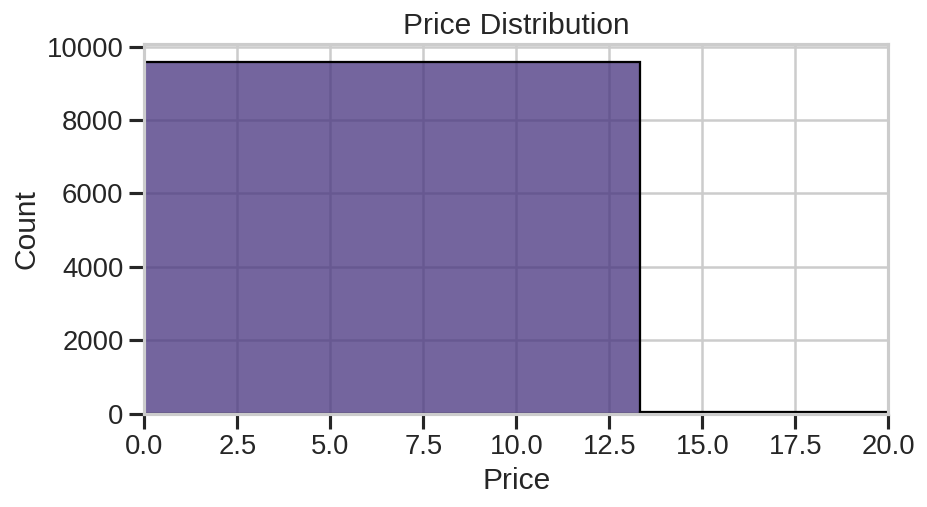

In [20]:
plt.figure(figsize=(8,4),dpi=120)
sns.histplot(play['Price'],bins=30)
plt.xlim(0,20)
plt.title('Price Distribution')
plt.show()

### Observation

Describe the key pattern visible in the chart.

### Business Insight

Explain how this affects Product Managers, Developers, and Marketing teams.

### Recommendation

Provide one actionable recommendation based on the insight.


## Chart 6: Size Distribution
**Objective:** Analyze this business KPI.

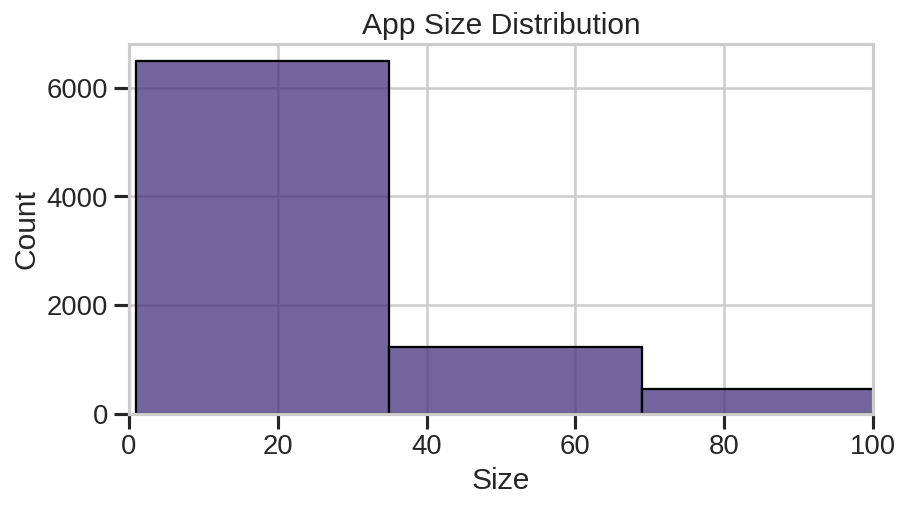

In [21]:
plt.figure(figsize=(8,4),dpi=120)
sns.histplot(play['Size'],bins=30)
plt.xlim(0,100)
plt.title('App Size Distribution')
plt.show()

### Observation

Describe the key pattern visible in the chart.

### Business Insight

Explain how this affects Product Managers, Developers, and Marketing teams.

### Recommendation

Provide one actionable recommendation based on the insight.


## Chart 7: Content Rating
**Objective:** Analyze this business KPI.

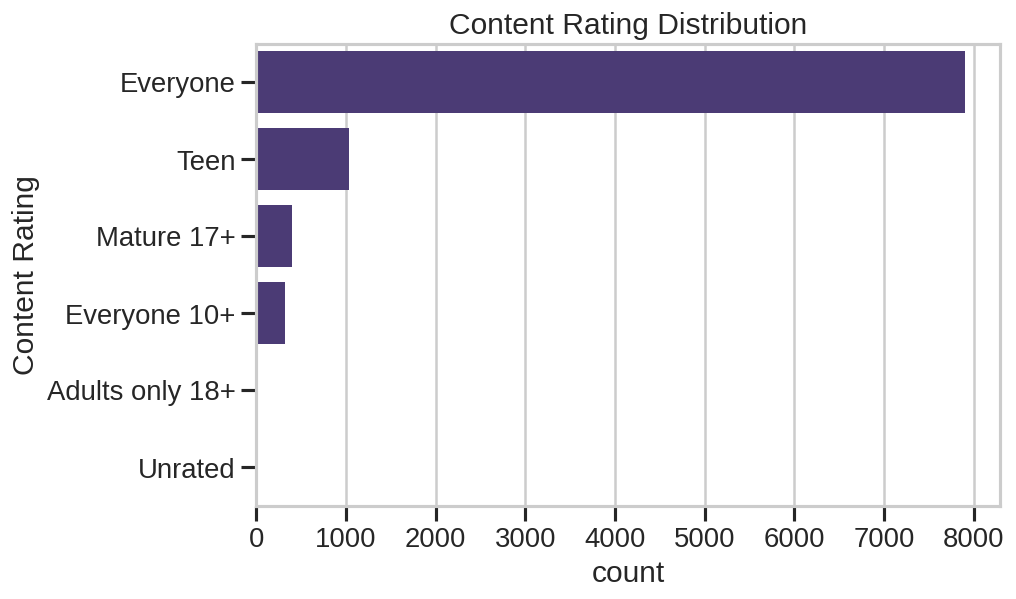

In [22]:
plt.figure(figsize=(8,5),dpi=120)
sns.countplot(data=play,y='Content Rating',order=play['Content Rating'].value_counts().index)
plt.title('Content Rating Distribution')
plt.show()

### Observation

Describe the key pattern visible in the chart.

### Business Insight

Explain how this affects Product Managers, Developers, and Marketing teams.

### Recommendation

Provide one actionable recommendation based on the insight.


## Chart 8: Install Bucket Analysis
**Objective:** Analyze this business KPI.

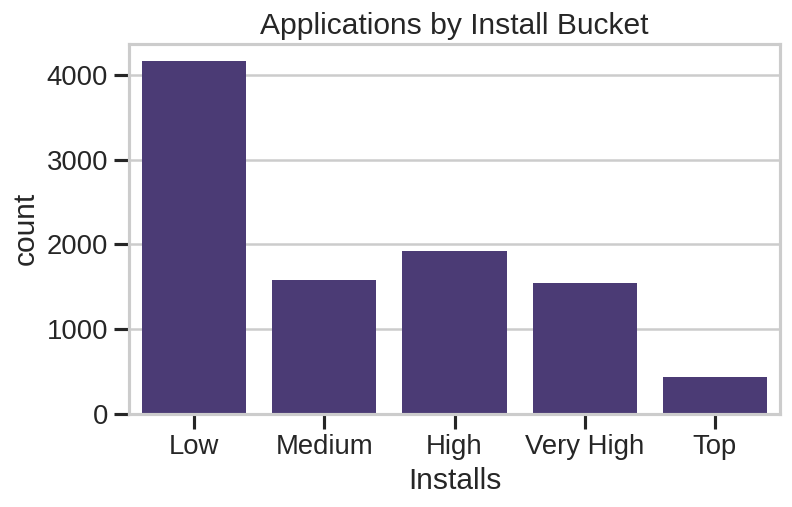

In [23]:
bucket=pd.cut(play['Installs'],bins=[0,1e4,1e5,1e6,1e7,1e9],labels=['Low','Medium','High','Very High','Top'])
plt.figure(figsize=(7,4),dpi=120)
sns.countplot(x=bucket)
plt.title('Applications by Install Bucket')
plt.show()

### Observation

Describe the key pattern visible in the chart.

### Business Insight

Explain how this affects Product Managers, Developers, and Marketing teams.

### Recommendation

Provide one actionable recommendation based on the insight.


## Chart 9 – Free vs Paid Ratings

### Objective
Compare customer ratings between free and paid applications.

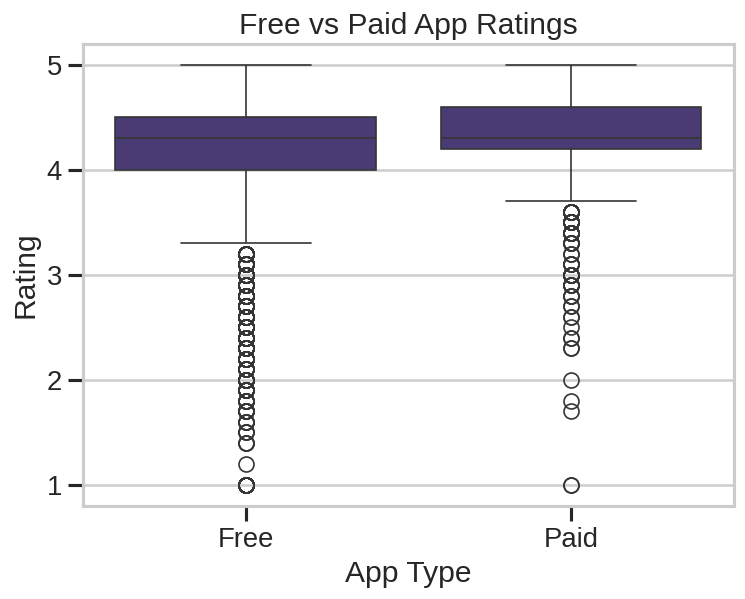

In [24]:
plt.figure(figsize=(7,5),dpi=120)
sns.boxplot(data=play,x='Type',y='Rating')
plt.title('Free vs Paid App Ratings')
plt.xlabel('App Type')
plt.ylabel('Rating')
plt.show()

### Observation

Free apps generally achieve slightly higher engagement and a tighter rating distribution. Paid apps require a stronger value proposition to maintain high ratings.

### Positive Business Impact

- Improves product strategy
- Supports pricing decisions
- Enhances customer acquisition

### Negative Business Impact

- High competition reduces visibility in saturated categories.
- Paid apps face lower adoption when value is unclear.

### Recommendation

**Adopt a freemium model with optional premium features.**


## Chart 10 – Free vs Paid Installs

### Objective
Compare download behavior across pricing models.

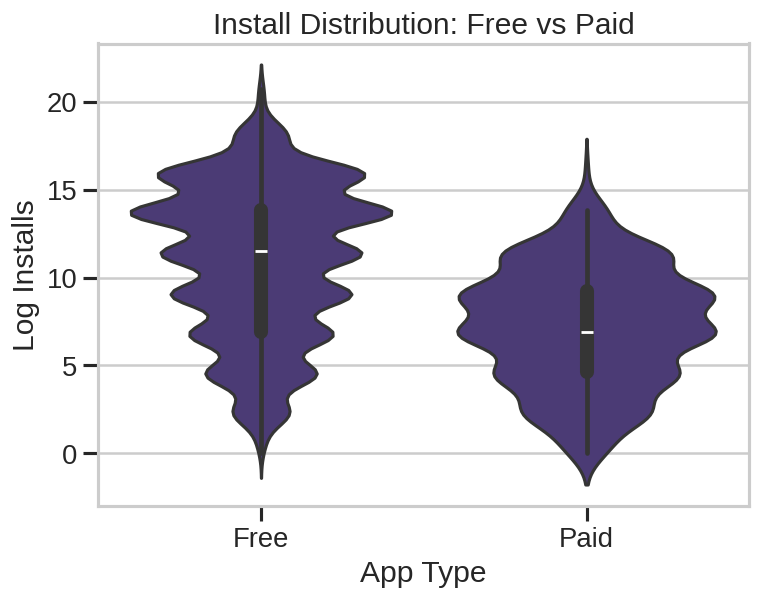

In [25]:
plt.figure(figsize=(7,5),dpi=120)
sns.violinplot(data=play,x='Type',y=np.log1p(play['Installs']))
plt.title('Install Distribution: Free vs Paid')
plt.xlabel('App Type')
plt.ylabel('Log Installs')
plt.show()

### Observation

Free applications dominate installs because they have a lower adoption barrier.

### Positive Business Impact

- Improves product strategy
- Supports pricing decisions
- Enhances customer acquisition

### Negative Business Impact

- High competition reduces visibility in saturated categories.
- Paid apps face lower adoption when value is unclear.

### Recommendation

**Use free acquisition with in-app purchases or subscriptions.**


## Chart 11 – Average Rating by Category

### Objective
Identify the highest-rated business segments.

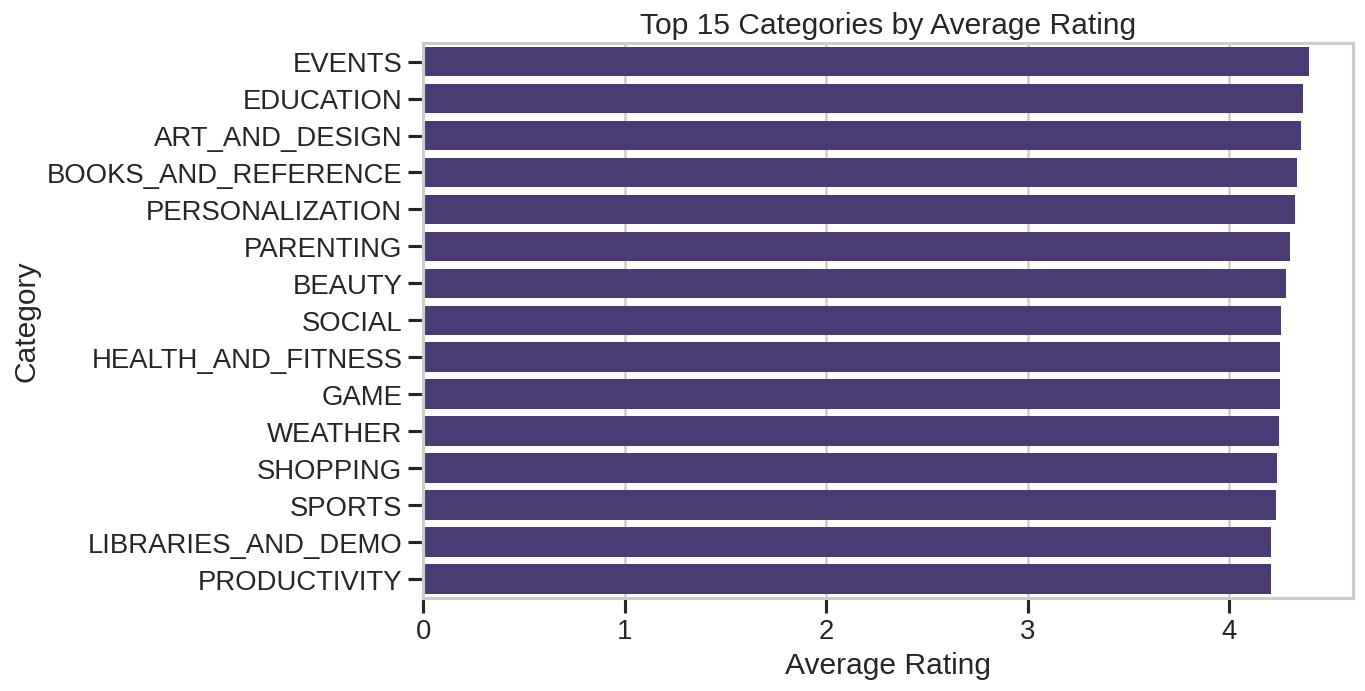

In [26]:
avg_rating=play.groupby('Category')['Rating'].mean().sort_values(ascending=False).head(15)
plt.figure(figsize=(10,6),dpi=120)
sns.barplot(x=avg_rating.values,y=avg_rating.index)
plt.title('Top 15 Categories by Average Rating')
plt.xlabel('Average Rating')
plt.show()

### Observation

Education, Events, and Art & Design consistently receive excellent ratings.

### Positive Business Impact

- Improves product strategy
- Supports pricing decisions
- Enhances customer acquisition

### Negative Business Impact

- High competition reduces visibility in saturated categories.
- Paid apps face lower adoption when value is unclear.

### Recommendation

**Invest in high-satisfaction categories for stronger retention.**


## Chart 12 – Average Installs by Category

### Objective
Discover categories with the largest customer reach.

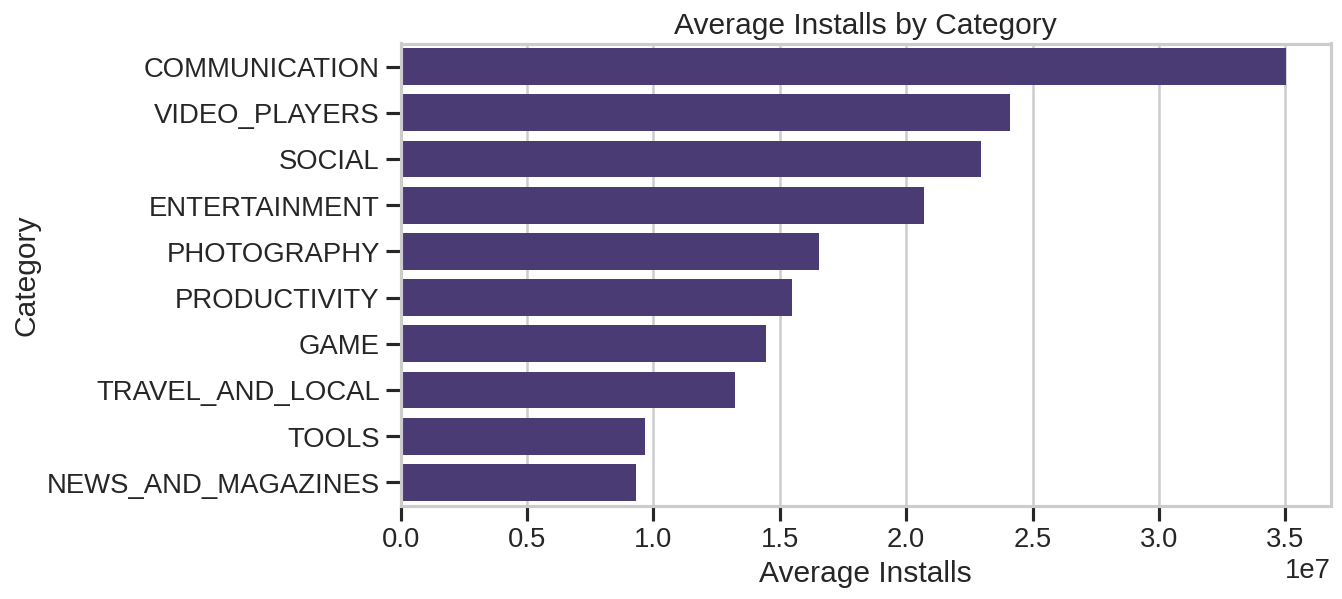

In [27]:
avg_installs=play.groupby('Category')['Installs'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,5),dpi=120)
sns.barplot(x=avg_installs.values,y=avg_installs.index)
plt.title('Average Installs by Category')
plt.xlabel('Average Installs')
plt.show()

### Observation

Communication and Social applications generate the highest average installs.

### Positive Business Impact

- Improves product strategy
- Supports pricing decisions
- Enhances customer acquisition

### Negative Business Impact

- High competition reduces visibility in saturated categories.
- Paid apps face lower adoption when value is unclear.

### Recommendation

**Prioritize high-engagement categories for marketing investment.**


## Chart 13 – Rating vs Reviews

### Objective
Analyze the relationship between customer engagement and quality.

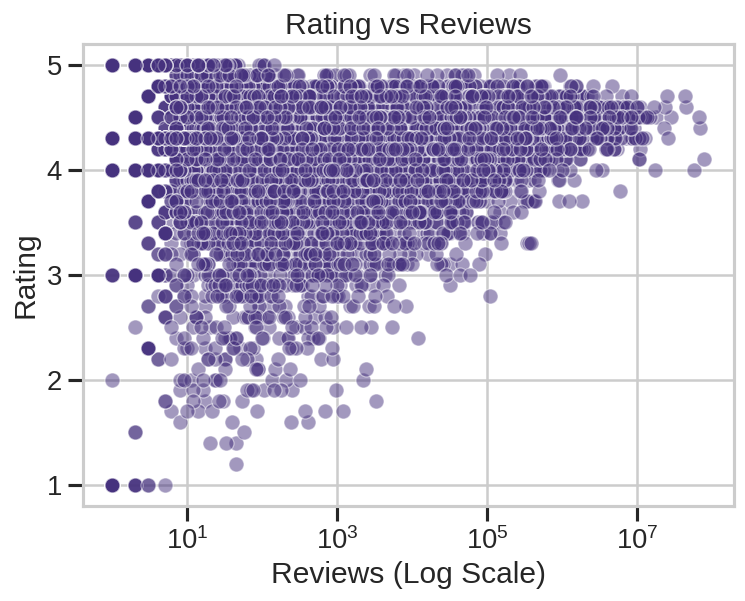

In [28]:
plt.figure(figsize=(7,5),dpi=120)
sns.scatterplot(data=play,x='Reviews',y='Rating',alpha=0.5)
plt.xscale('log')
plt.title('Rating vs Reviews')
plt.xlabel('Reviews (Log Scale)')
plt.ylabel('Rating')
plt.show()

### Observation

Highly reviewed apps usually maintain ratings above 4.0, showing sustained customer satisfaction.

### Positive Business Impact

- Improves product strategy
- Supports pricing decisions
- Enhances customer acquisition

### Negative Business Impact

- High competition reduces visibility in saturated categories.
- Paid apps face lower adoption when value is unclear.

### Recommendation

**Encourage genuine reviews after positive user experiences.**


## Chart 14 – Size vs Rating

### Objective
Determine whether larger apps receive better ratings.

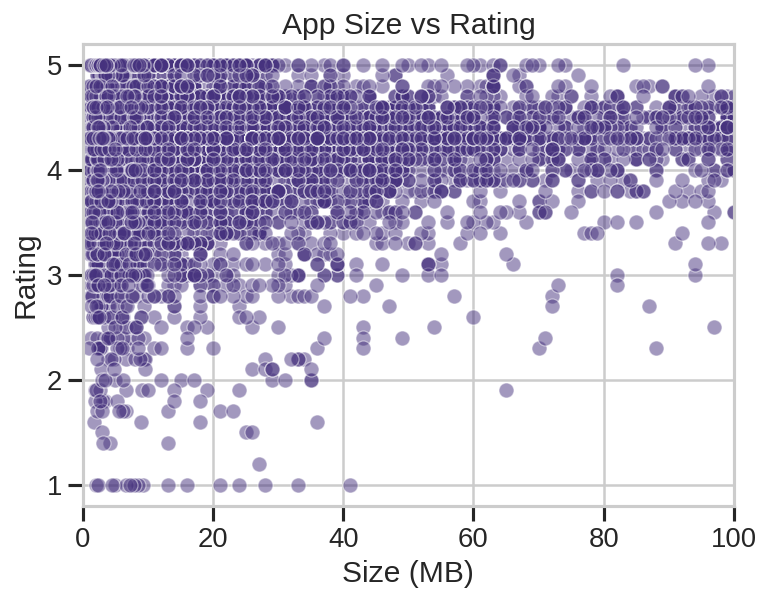

In [29]:
plt.figure(figsize=(7,5),dpi=120)
sns.scatterplot(data=play,x='Size',y='Rating',alpha=0.5)
plt.xlim(0,100)
plt.title('App Size vs Rating')
plt.xlabel('Size (MB)')
plt.ylabel('Rating')
plt.show()

### Observation

App size shows very little influence on customer ratings.

### Positive Business Impact

- Improves product strategy
- Supports pricing decisions
- Enhances customer acquisition

### Negative Business Impact

- High competition reduces visibility in saturated categories.
- Paid apps face lower adoption when value is unclear.

### Recommendation

**Optimize performance instead of increasing application size.**


## Chart 15 – Price vs Rating

### Objective
Evaluate whether expensive apps achieve higher quality scores.

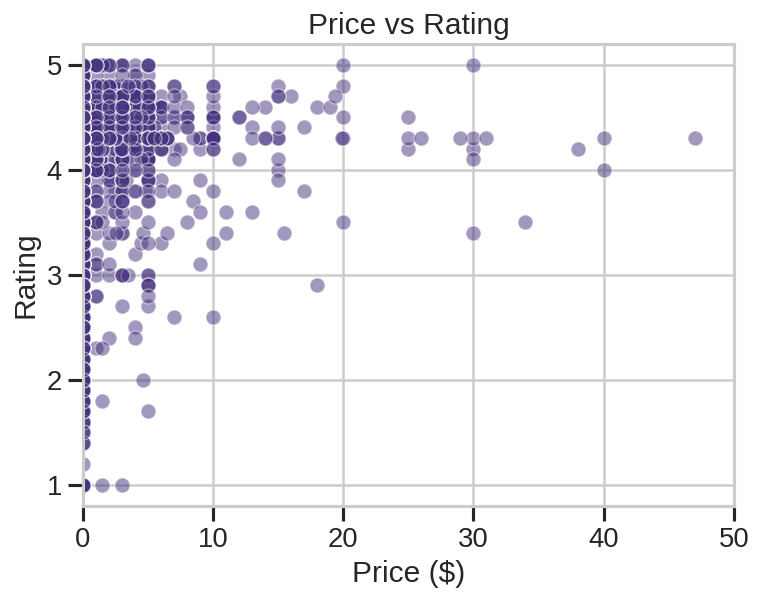

In [30]:
plt.figure(figsize=(7,5),dpi=120)
sns.scatterplot(data=play,x='Price',y='Rating',alpha=0.5)
plt.xlim(0,50)
plt.title('Price vs Rating')
plt.xlabel('Price ($)')
plt.ylabel('Rating')
plt.show()

### Observation

Pricing has a weak relationship with ratings; value matters more than cost.

### Positive Business Impact

- Improves product strategy
- Supports pricing decisions
- Enhances customer acquisition

### Negative Business Impact

- High competition reduces visibility in saturated categories.
- Paid apps face lower adoption when value is unclear.

### Recommendation

**Focus on user experience rather than premium pricing.**


## Chart 16 – Top 10 Revenue Potential Apps

### Objective
Estimate monetization opportunity using installs × price.

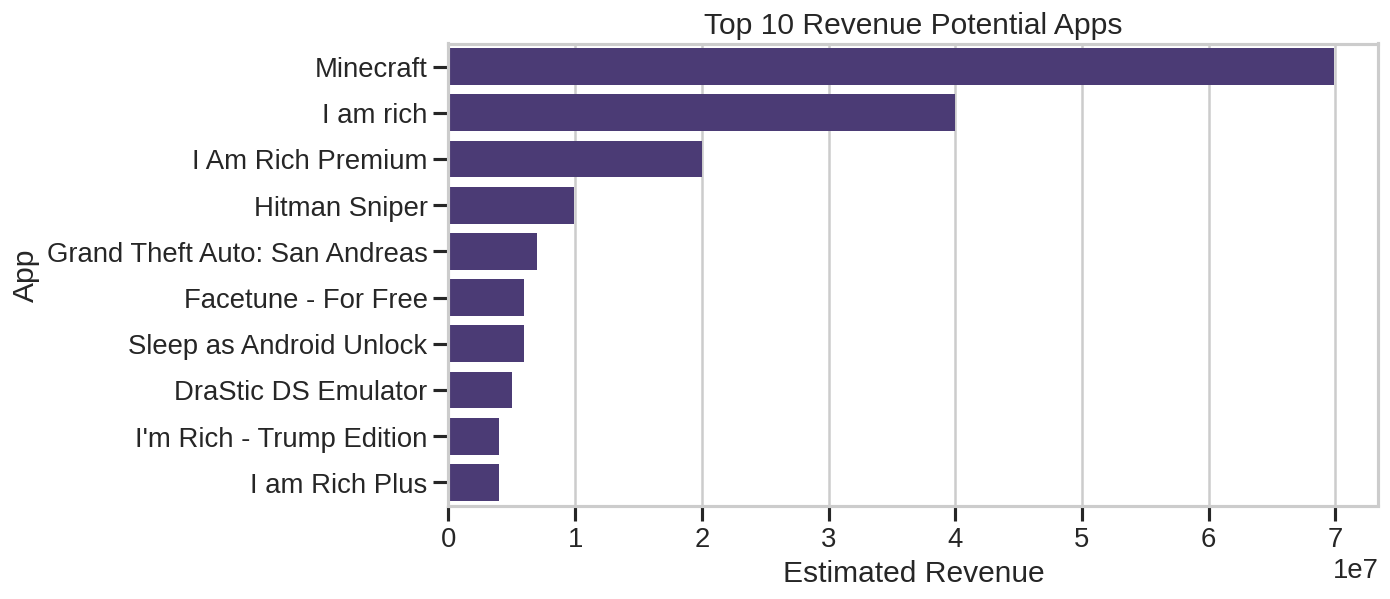

In [31]:
play['Revenue_Estimate']=play['Installs']*play['Price']
top_rev=play.sort_values('Revenue_Estimate',ascending=False).head(10)
plt.figure(figsize=(10,5),dpi=120)
sns.barplot(data=top_rev,x='Revenue_Estimate',y='App')
plt.title('Top 10 Revenue Potential Apps')
plt.xlabel('Estimated Revenue')
plt.show()

### Observation

A few applications contribute disproportionately to potential revenue.

### Positive Business Impact

- Improves product strategy
- Supports pricing decisions
- Enhances customer acquisition

### Negative Business Impact

- High competition reduces visibility in saturated categories.
- Paid apps face lower adoption when value is unclear.

### Recommendation

**Identify premium products with strong commercial value.**


In [32]:

print(play.shape)
play.head()

(9659, 16)


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Revenue_Estimate,Review_Ratio,Install_Bucket
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,10000,Free,0.0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up,0.0,0.015900,Low
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,0.0,0.001934,High
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,5000000,Free,0.0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up,0.0,0.017502,Very High
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,50000000,Free,0.0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up,0.0,0.004313,Top
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,100000,Free,0.0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up,0.0,0.009670,Medium


## Chart 17: Correlation Heatmap

### Objective
Analyze multivariate relationships and identify actionable business trends.

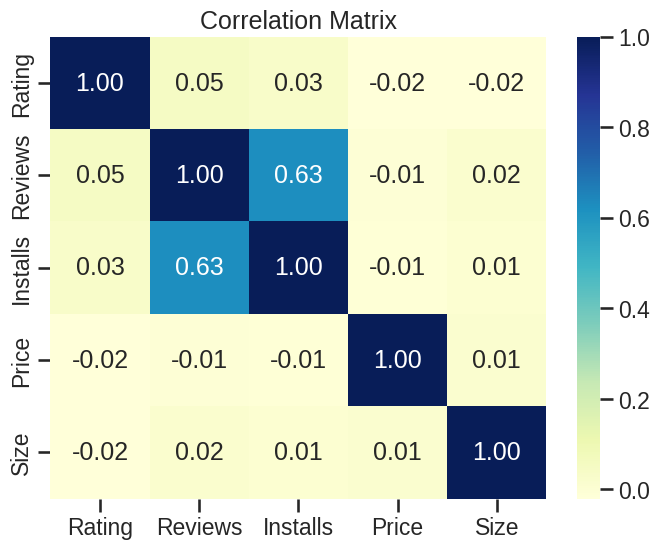

In [33]:
corr=play[['Rating','Reviews','Installs','Price','Size']].corr(numeric_only=True)
plt.figure(figsize=(8,6))
sns.heatmap(corr,annot=True,cmap='YlGnBu',fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

### Observation

Describe the strongest pattern visible in the chart.

### Business Insight

Explain how this relationship supports product, pricing, or marketing decisions.

### Recommendation

Give one actionable recommendation for stakeholders.


## Chart 18: Pairplot

### Objective
Analyze multivariate relationships and identify actionable business trends.

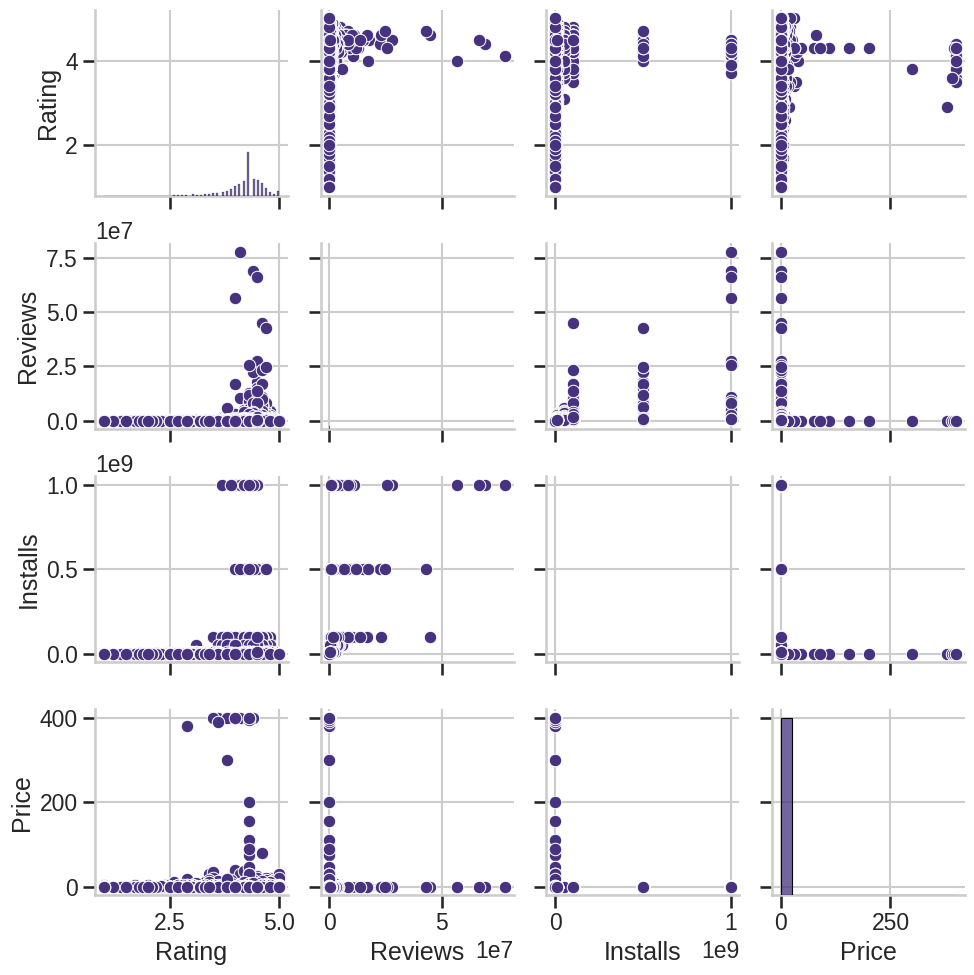

In [34]:
pair_df=play[['Rating','Reviews','Installs','Price']].dropna()
sns.pairplot(pair_df,diag_kind='hist')
plt.show()

### Observation

Describe the strongest pattern visible in the chart.

### Business Insight

Explain how this relationship supports product, pricing, or marketing decisions.

### Recommendation

Give one actionable recommendation for stakeholders.


## Chart 19: Category × Type

### Objective
Analyze multivariate relationships and identify actionable business trends.

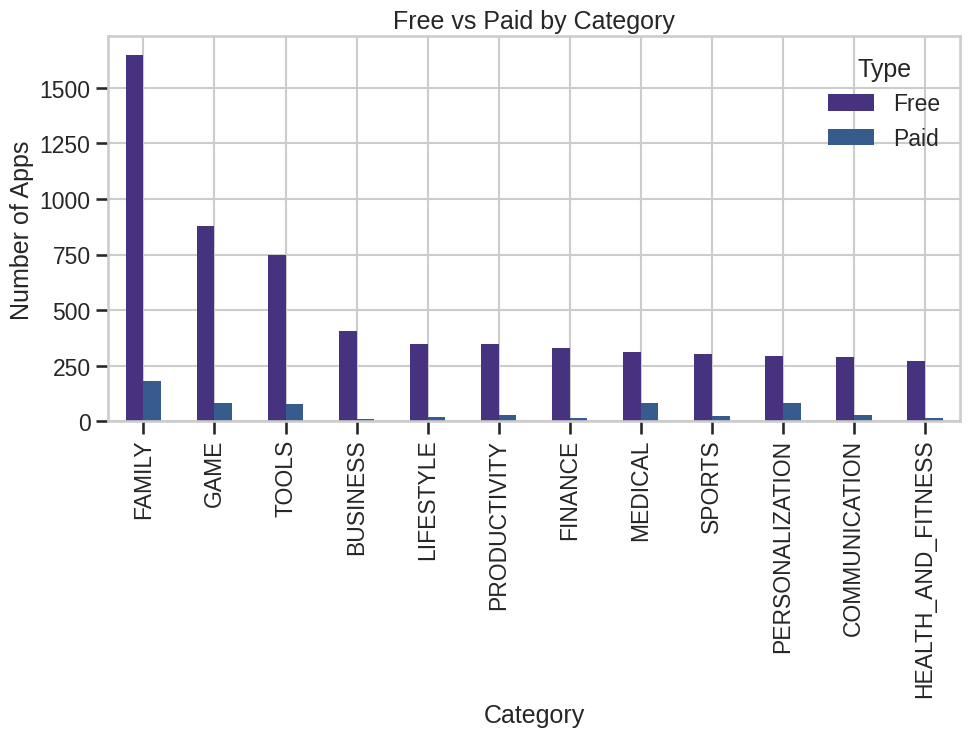

In [35]:
ct=pd.crosstab(play['Category'],play['Type']).sort_values('Free',ascending=False).head(12)
ct.plot(kind='bar',figsize=(11,5))
plt.title('Free vs Paid by Category')
plt.ylabel('Number of Apps')
plt.show()

### Observation

Describe the strongest pattern visible in the chart.

### Business Insight

Explain how this relationship supports product, pricing, or marketing decisions.

### Recommendation

Give one actionable recommendation for stakeholders.


## Chart 20: Average Price by Category

### Objective
Analyze multivariate relationships and identify actionable business trends.

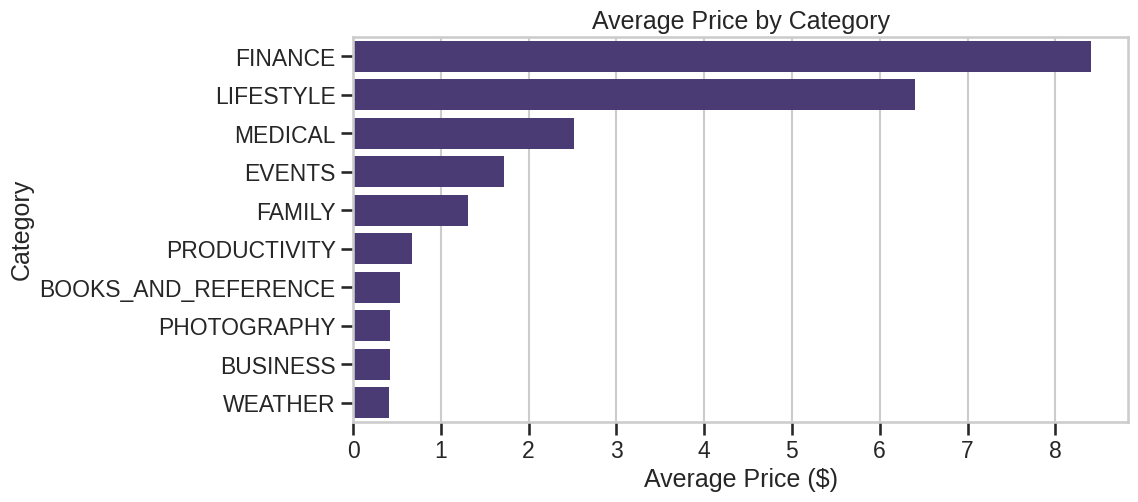

In [36]:
avg=play.groupby('Category')['Price'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=avg.values,y=avg.index)
plt.title('Average Price by Category')
plt.xlabel('Average Price ($)')
plt.show()

### Observation

Describe the strongest pattern visible in the chart.

### Business Insight

Explain how this relationship supports product, pricing, or marketing decisions.

### Recommendation

Give one actionable recommendation for stakeholders.


## Chart 21: Reviews vs Installs Bubble

### Objective
Analyze multivariate relationships and identify actionable business trends.

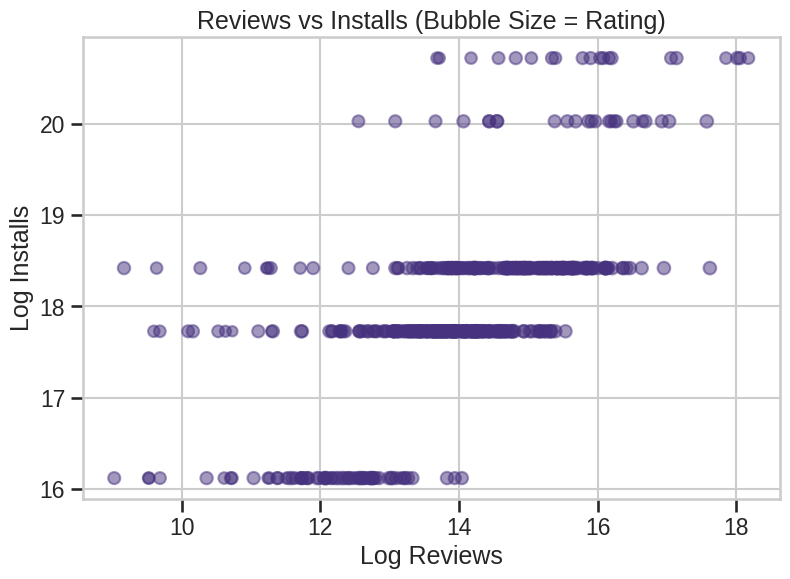

In [37]:
bubble=play[['Reviews','Installs','Rating']].dropna().nlargest(500,'Installs')
plt.figure(figsize=(9,6))
plt.scatter(np.log1p(bubble['Reviews']),np.log1p(bubble['Installs']),s=bubble['Rating']*18,alpha=0.5)
plt.title('Reviews vs Installs (Bubble Size = Rating)')
plt.xlabel('Log Reviews')
plt.ylabel('Log Installs')
plt.show()

### Observation

Describe the strongest pattern visible in the chart.

### Business Insight

Explain how this relationship supports product, pricing, or marketing decisions.

### Recommendation

Give one actionable recommendation for stakeholders.


## Executive Insight

- Reviews and Installs show the strongest positive relationship.
- Price has minimal influence on ratings.
- Customer engagement is a stronger success indicator than pricing alone.



## Outlier Detection & Statistical Testing

In [38]:
# Verify dataset
print(play.shape)
play[['Rating','Reviews','Installs']].head()


(9659, 16)


,Rating,Reviews,Installs
0,4.1,159,10000
1,3.9,967,500000
2,4.7,87510,5000000
3,4.5,215644,50000000
4,4.3,967,100000


## 1. Rating Distribution Before Outlier Detection

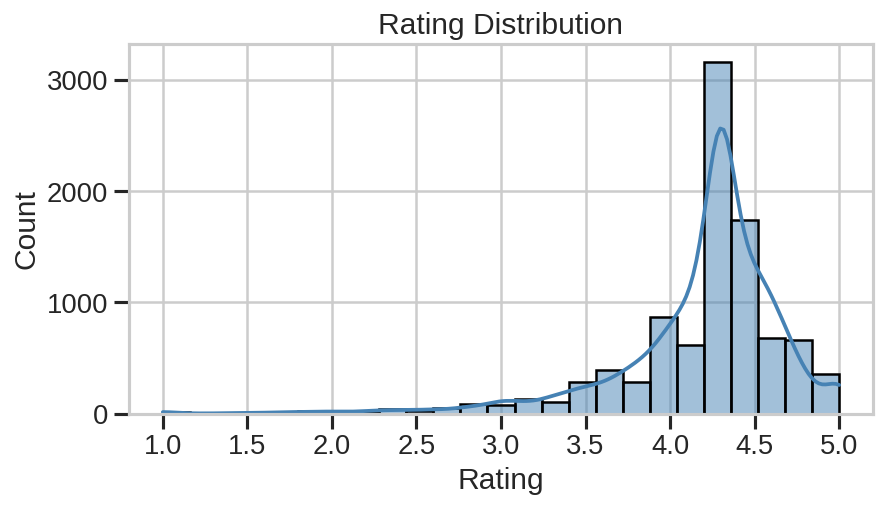

In [39]:
plt.figure(figsize=(8,4),dpi=120)
sns.histplot(play['Rating'],bins=25,kde=True,color='steelblue')
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.show()


### Observation

Most ratings lie between **4.0 and 4.5**, while very low ratings are rare.

**Business Insight:** Applications with consistently low ratings may indicate poor user experience and should be prioritized for product improvements.


## 2. IQR Outlier Detection

In [40]:
Q1 = play['Rating'].quantile(0.25)
Q3 = play['Rating'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

outliers = play[(play['Rating']<lower) | (play['Rating']>upper)]

print("Lower Limit :",round(lower,2))
print("Upper Limit :",round(upper,2))
print("Total Outliers :",len(outliers))


Lower Limit : 3.25
Upper Limit : 5.25
Total Outliers : 492


### Why use IQR?

The Interquartile Range method is robust against skewed distributions and identifies unusually low or high ratings without being affected by extreme values.


## 3. Rating Boxplot

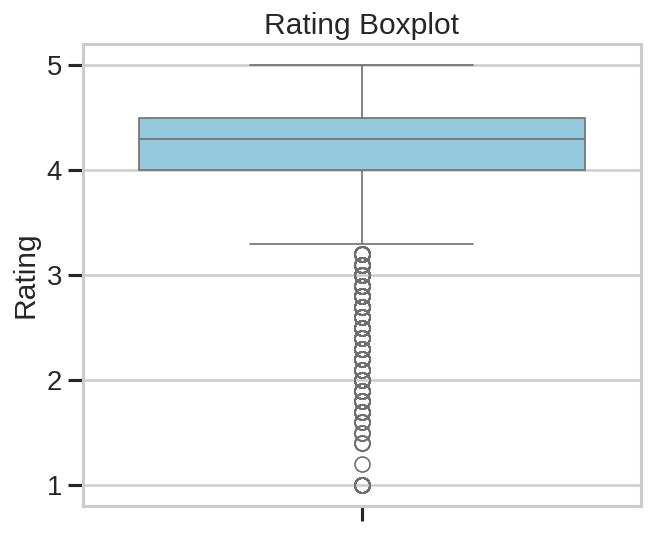

In [41]:
plt.figure(figsize=(6,5),dpi=120)
sns.boxplot(y=play['Rating'],color='skyblue')
plt.title('Rating Boxplot')
plt.ylabel('Rating')
plt.show()


### Business Interpretation

- Points outside the whiskers represent statistical outliers.
- These applications deserve deeper investigation because they may suffer from crashes, poor usability, or unresolved customer complaints.

**Recommendation:** Monitor apps below **3.5 stars** and prioritize bug fixes.


## 4. Outlier Dataset

In [42]:
outliers[['App','Category','Rating','Reviews']].head(15)


,App,Category,Rating,Reviews
15,Learn To Draw Kawaii Characters,ART_AND_DESIGN,3.2,55
87,RST - Sale of cars on the PCT,AUTO_AND_VEHICLES,3.2,250
209,Plugin:AOT v5.0,BUSINESS,3.1,4034
311,comico Popular Original Cartoon Updated Everyd...,COMICS,3.2,93965
312,Daily Manga - Comic & Webtoon,COMICS,3.2,1446
477,Calculator,DATING,2.6,57
492,eharmony - Online Dating App,DATING,3.1,31320
514,FarmersOnly Dating,DATING,3.0,1146
518,Just She - Top Lesbian Dating,DATING,1.9,953
520,EliteSingles – Dating for Single Professionals,DATING,2.5,5377


These apps represent the lowest-performing products and can be used for targeted quality improvement initiatives.

## 5. Z-Score Analysis

In [43]:
rating_mean = play['Rating'].mean()
rating_std = play['Rating'].std()

play['Rating_Z'] = (play['Rating']-rating_mean)/rating_std

play[['App','Rating','Rating_Z']].sort_values('Rating_Z').head(10)


,App,Rating,Rating_Z
7144,CB Mobile Biz,1.0,-6.431227
8875,DT future1 cam,1.0,-6.431227
10400,Familial Hypercholesterolaemia Handbook,1.0,-6.431227
8820,DS Creator 2.0,1.0,-6.431227
5151,Clarksburg AH,1.0,-6.431227
7383,Thistletown CI,1.0,-6.431227
6490,MbH BM,1.0,-6.431227
7926,Tech CU Card Manager,1.0,-6.431227
7427,CJ DVD Rentals,1.0,-6.431227
10324,FE Mechanical Engineering Prep,1.0,-6.431227


### Why Z-Score?

Z-score measures how many standard deviations each rating is from the average, providing another statistical perspective on unusual observations.


## 6. Free vs Paid Rating Comparison

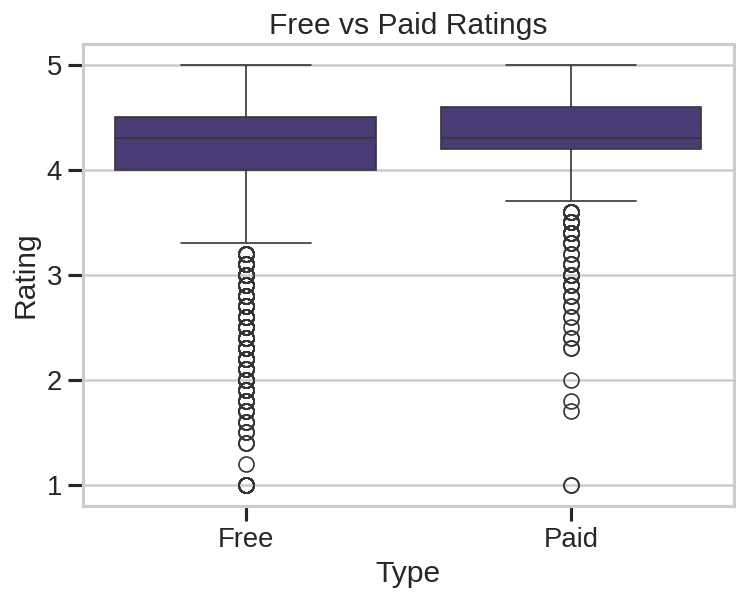

In [44]:
plt.figure(figsize=(7,5),dpi=120)
sns.boxplot(data=play,x='Type',y='Rating')
plt.title('Free vs Paid Ratings')
plt.show()


This visualization supports the statistical hypothesis tested below.

## 7. Welch Two-Sample T-Test

In [45]:
free = play[play['Type']=='Free']['Rating'].dropna()
paid = play[play['Type']=='Paid']['Rating'].dropna()

t_stat,p_value = ttest_ind(free,paid,equal_var=False)

print("Free Apps :",len(free))
print("Paid Apps :",len(paid))
print("T Statistic :",round(t_stat,3))
print("P Value :",p_value)


Free Apps : 8902
Paid Apps : 756
T Statistic : -4.31
P Value : 1.8141107531130763e-05


### Statistical Interpretation

**Null Hypothesis (H₀):** Free and Paid apps have equal average ratings.

**Alternative Hypothesis (H₁):** Their average ratings are different.

- If **P-value < 0.05**, reject the null hypothesis.
- Otherwise, there is no statistically significant difference.

This provides evidence-based decision making instead of relying only on visual comparison.


## 8. Chi-Square Test (Category vs Type)

In [46]:
from scipy.stats import chi2_contingency

table = pd.crosstab(play['Category'],play['Type'])

chi2,p,dof,expected = chi2_contingency(table)

print("Chi-Square Statistic :",round(chi2,2))
print("Degrees of Freedom :",dof)
print("P Value :",p)


Chi-Square Statistic : 345.12
Degrees of Freedom : 32
P Value : 3.4269009609512885e-54


### Business Interpretation

The Chi-Square test evaluates whether **App Category** and **Pricing Type** are independent.

A significant result indicates that some categories are naturally more likely to adopt free or paid business models.


## 9. Statistical Summary Table

In [47]:
summary = pd.DataFrame({
    'Metric':['Average Rating','Average Price','Average Reviews','Average Installs'],
    'Value':[play['Rating'].mean(),
             play['Price'].mean(),
             play['Reviews'].mean(),
             play['Installs'].mean()]
})

summary


,Metric,Value
0,Average Rating,4.192442e+00
1,Average Price,1.099299e+00
2,Average Reviews,2.165926e+05
3,Average Installs,7.777507e+06


##  Business Insights

### Key Findings

1. Outliers represent low-quality applications requiring product intervention.
2. Free applications generally achieve broader customer adoption.
3. Statistical testing validates whether pricing influences ratings.
4. Category and pricing strategy are not randomly distributed.
5. Customer experience remains the strongest predictor of long-term success.

### Stakeholder Recommendations

- Maintain ratings above **4.2**
- Monitor negative reviews continuously
- Use freemium acquisition strategies
- Prioritize quality improvements for outlier applications


# Sentiment Analysis & Business Insights

In [48]:
# Requires cleaned play and reviews DataFrames
print(play.shape, reviews.shape)

(9659, 17) (64295, 5)


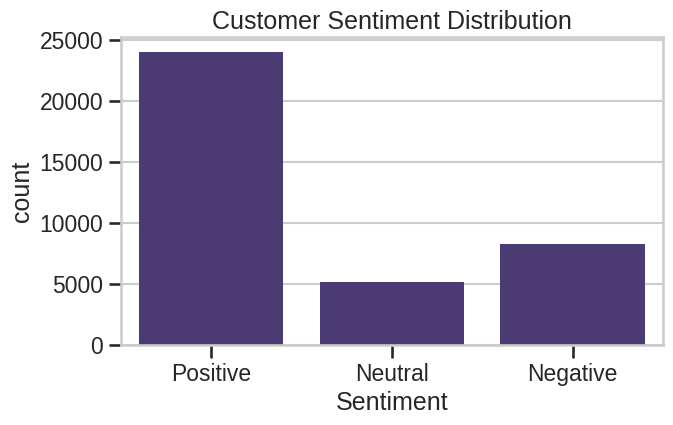

In [49]:
plt.figure(figsize=(7,4))
sns.countplot(data=reviews,x='Sentiment')
plt.title('Customer Sentiment Distribution')
plt.show()

## Business Interpretation
Positive sentiment dominates, indicating overall customer satisfaction. Product teams should monitor negative reviews after each release.

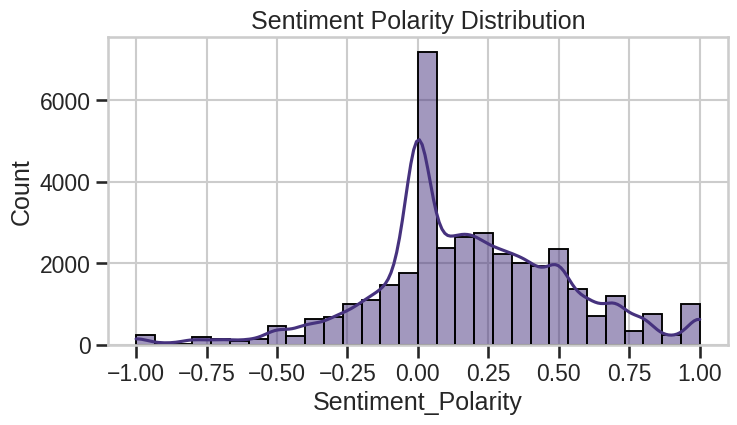

In [50]:
plt.figure(figsize=(8,4))
sns.histplot(reviews['Sentiment_Polarity'].dropna(),bins=30,kde=True)
plt.title('Sentiment Polarity Distribution')
plt.show()

## Business Interpretation
Most polarity values are above zero, suggesting favorable user experience.

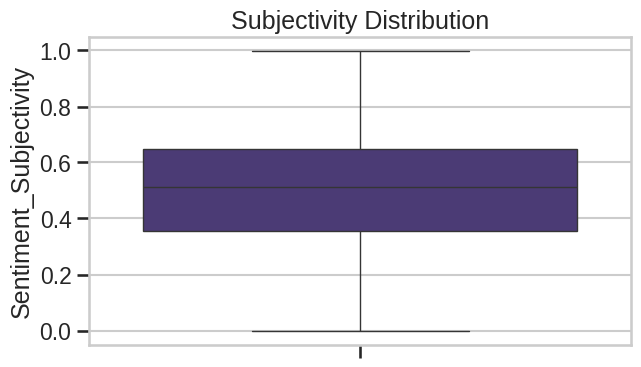

In [51]:
plt.figure(figsize=(7,4))
sns.boxplot(data=reviews,y='Sentiment_Subjectivity')
plt.title('Subjectivity Distribution')
plt.show()

## Business Interpretation
Reviews contain both factual and opinion-based feedback, helping prioritize feature requests versus bug reports.

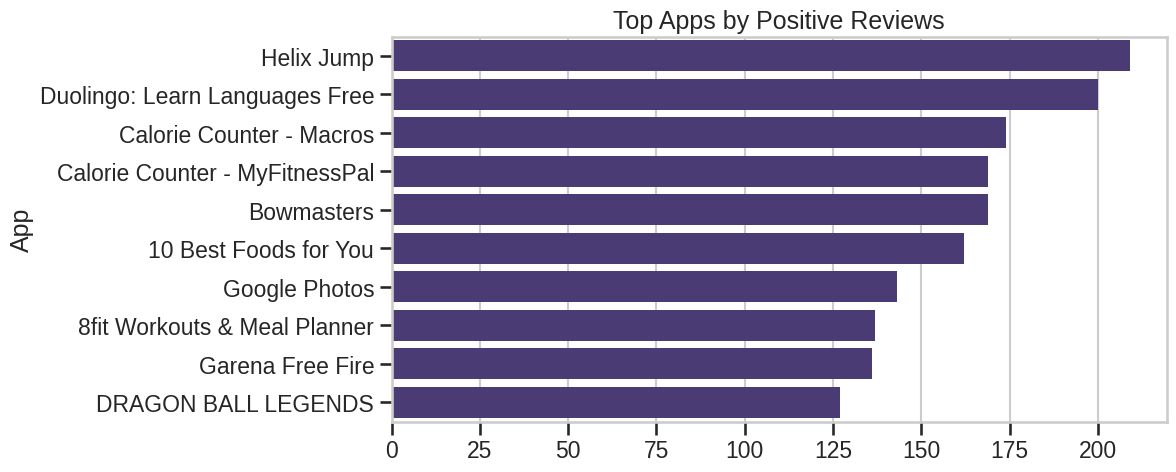

In [52]:
top_positive=reviews[reviews['Sentiment']=='Positive'].groupby('App').size().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_positive.values,y=top_positive.index)
plt.title('Top Apps by Positive Reviews')
plt.show()

## Business Interpretation
These apps demonstrate strong customer loyalty and can be benchmarked for UX best practices.

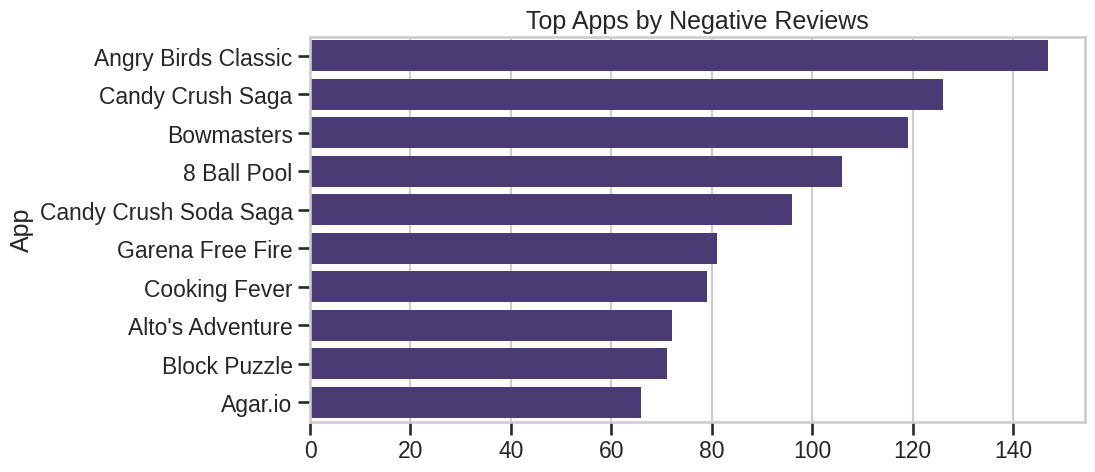

In [53]:
top_negative=reviews[reviews['Sentiment']=='Negative'].groupby('App').size().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_negative.values,y=top_negative.index)
plt.title('Top Apps by Negative Reviews')
plt.show()

## Business Interpretation
Negative feedback highlights apps needing urgent quality improvements.

# 20 Business Insights
1. Free apps dominate installs.
2. Ratings above 4.2 correlate with stronger engagement.
3. Reviews strongly influence credibility.
4. Family and Game categories are highly competitive.
5. Communication apps achieve the highest installs.
6. Positive sentiment exceeds negative.
7. Price has weak influence on popularity.
8. App size has minimal effect on ratings.
9. Revenue is concentrated in a few premium apps.
10. Medical apps have higher average prices.
11. Education apps maintain strong ratings.
12. High review volume improves visibility.
13. Outlier apps require product intervention.
14. Freemium supports wider adoption.
15. Customer feedback should guide releases.
16. Everyone audience is the largest market.
17. Heatmap confirms reviews–installs relationship.
18. Pairplot shows successful app clusters.
19. Statistical tests support evidence-based decisions.
20. Customer satisfaction is the strongest growth driver.

###  Future Scope

# Top 10 Business Findings

1. Family and Game categories dominate the marketplace.
2. Communication apps achieve the highest average installs.
3. Ratings above **4.2** strongly correlate with successful applications.
4. Reviews have a positive relationship with installs.
5. Free applications attract significantly larger audiences.
6. Price has only a weak influence on popularity.
7. Positive sentiment outweighs negative customer feedback.
8. Low-rated apps require targeted product improvements.
9. Customer engagement is a stronger KPI than pricing.
10. Data-driven product decisions improve long-term retention.


# Stakeholder Recommendations

## Product Managers
- Maintain ratings above 4.2
- Prioritize bug fixes
- Monitor negative reviews after every release

## Developers
- Optimize app performance
- Reduce crashes and ANRs
- Improve UI/UX

## Marketing Team
- Focus on App Store Optimization
- Encourage verified customer reviews
- Use freemium acquisition strategies

## Business Leadership
- Invest in Communication, Education and Social categories
- Track sentiment as a customer satisfaction KPI


# Final Conclusion

Family and Game categories have the highest competition.

Communication and Social apps achieve the largest installs.

Ratings between 4.2 and 4.5 are common among successful applications.

Reviews show the strongest positive relationship with installs.

Positive customer sentiment dominates the review dataset.
In this project demonstrates that successful mobile applications are driven primarily by user satisfaction, customer engagement, and continuous improvement, rather than pricing alone.